In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from itertools import chain
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score

import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16')

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for gpu in gpus:
    print(f"  - {gpu}")

strategy = tf.distribute.MirroredStrategy()
NUM_GPUS = strategy.num_replicas_in_sync
print(f"Training will use {NUM_GPUS} device(s)")

import warnings
warnings.filterwarnings('ignore')

2026-04-11 12:06:00.093737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775909160.275357      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775909160.327100      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775909160.743726      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775909160.743776      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775909160.743779      55 computation_placer.cc:177] computation placer alr

GPUs available: 2
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Training will use 2 device(s)


I0000 00:00:1775909184.813680      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775909184.819746      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
# Data preparing Cell

BASE_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
CSV_PATH = os.path.join(BASE_DIR, 'Data_Entry_2017.csv')

# --- 0. Build filename → full path lookup ---
print("0. Scanning image folders...")
all_image_paths = glob(os.path.join(BASE_DIR, 'images_*/images/*.png'))
print(f"   Found {len(all_image_paths):,} images")
assert len(all_image_paths) > 0, "No images found — check BASE_DIR"

fname_to_path = {os.path.basename(p): p for p in all_image_paths}

# --- 1. Load CSV ---
print("\n1. Loading CSV...")
data = pd.read_csv(CSV_PATH)
data = data[data['Patient Age'] < 100].reset_index(drop=True)

data['path'] = data['Image Index'].map(fname_to_path)
missing = data['path'].isna().sum()
if missing > 0:
    print(f"   Warning: {missing} rows had no matching file — dropping.")
data = data.dropna(subset=['path']).reset_index(drop=True)
print(f"   {len(data):,} records with valid paths")

# --- 2. Process labels ---
print("\n2. Processing labels...")
data['Finding Labels'] = data['Finding Labels'].str.replace('No Finding', '', regex=False)

all_labels_raw = np.unique(list(chain(
    *data['Finding Labels'].map(lambda x: x.split('|')).tolist()
)))
all_labels_raw = [x for x in all_labels_raw if x.strip()]

for label in all_labels_raw:
    data[label] = data['Finding Labels'].map(
        lambda x, l=label: 1.0 if l in x else 0.0
    )

MIN_CASES = 1000
all_labels = [c for c in all_labels_raw if data[c].sum() > MIN_CASES]
print(f"   {len(all_labels)} diseases kept: {all_labels}")

# --- 3. Weighted sampling & split ---
print("\n3. Sampling and splitting...")
sample_weights = data['Finding Labels'].map(
    lambda x: len([s for s in x.split('|') if s.strip()])
).values.astype(float)
sample_weights += 4e-2
sample_weights /= sample_weights.sum()

data_sampled = data.sample(40_000, weights=sample_weights, random_state=2018)

train_df, test_df = train_test_split(
    data_sampled, test_size=0.20, random_state=2018,
    stratify=data_sampled['Finding Labels'].map(lambda x: x[:4])
)
train_df, valid_df = train_test_split(
    train_df, test_size=0.10, random_state=2018,
    stratify=train_df['Finding Labels'].map(lambda x: x[:4])
)
print(f"   Train: {len(train_df):,} | Val: {len(valid_df):,} | Test: {len(test_df):,}")

0. Scanning image folders...
   Found 112,120 images

1. Loading CSV...
   112,104 records with valid paths

2. Processing labels...
   13 diseases kept: [np.str_('Atelectasis'), np.str_('Cardiomegaly'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Effusion'), np.str_('Emphysema'), np.str_('Fibrosis'), np.str_('Infiltration'), np.str_('Mass'), np.str_('Nodule'), np.str_('Pleural_Thickening'), np.str_('Pneumonia'), np.str_('Pneumothorax')]

3. Sampling and splitting...
   Train: 28,800 | Val: 3,200 | Test: 8,000


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE_PER_GPU = 64
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_GPU * NUM_GPUS
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    """Read a PNG from disk and resize it. Runs in parallel."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    """Training-time augmentations (runs on tensors, not PIL)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    # Small random rotation via affine (±10 degrees)
    angle = tf.random.uniform([], -10.0, 10.0) * (3.14159 / 180.0)
    img = tf.keras.ops.image.affine_transform(
        tf.expand_dims(img, 0),
        tf.concat([tf.cos(angle)[tf.newaxis], -tf.sin(angle)[tf.newaxis],
                   tf.zeros([1]), tf.sin(angle)[tf.newaxis],
                   tf.cos(angle)[tf.newaxis], tf.zeros([3])], axis=0)[tf.newaxis],
    )[0]
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_dataset(df, training=False):
    """Build a fast tf.data pipeline from a DataFrame."""
    paths = df['path'].values
    labels = df[all_labels].values.astype('float32')

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    # Parallel image loading — this is where the speed comes from
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(GLOBAL_BATCH_SIZE if training else GLOBAL_BATCH_SIZE * 2)

    # Prefetch next batch while GPU processes current one
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = build_dataset(train_df, training=True)
valid_ds = build_dataset(valid_df, training=False)
test_ds  = build_dataset(test_df,  training=False)

print(f"Global batch size: {GLOBAL_BATCH_SIZE} ({NUM_GPUS} GPU(s) × {BATCH_SIZE_PER_GPU})")
print("tf.data pipelines ready — parallel loading + prefetching enabled")

Global batch size: 128 (2 GPU(s) × 64)
tf.data pipelines ready — parallel loading + prefetching enabled


Fetching one batch for visualization...


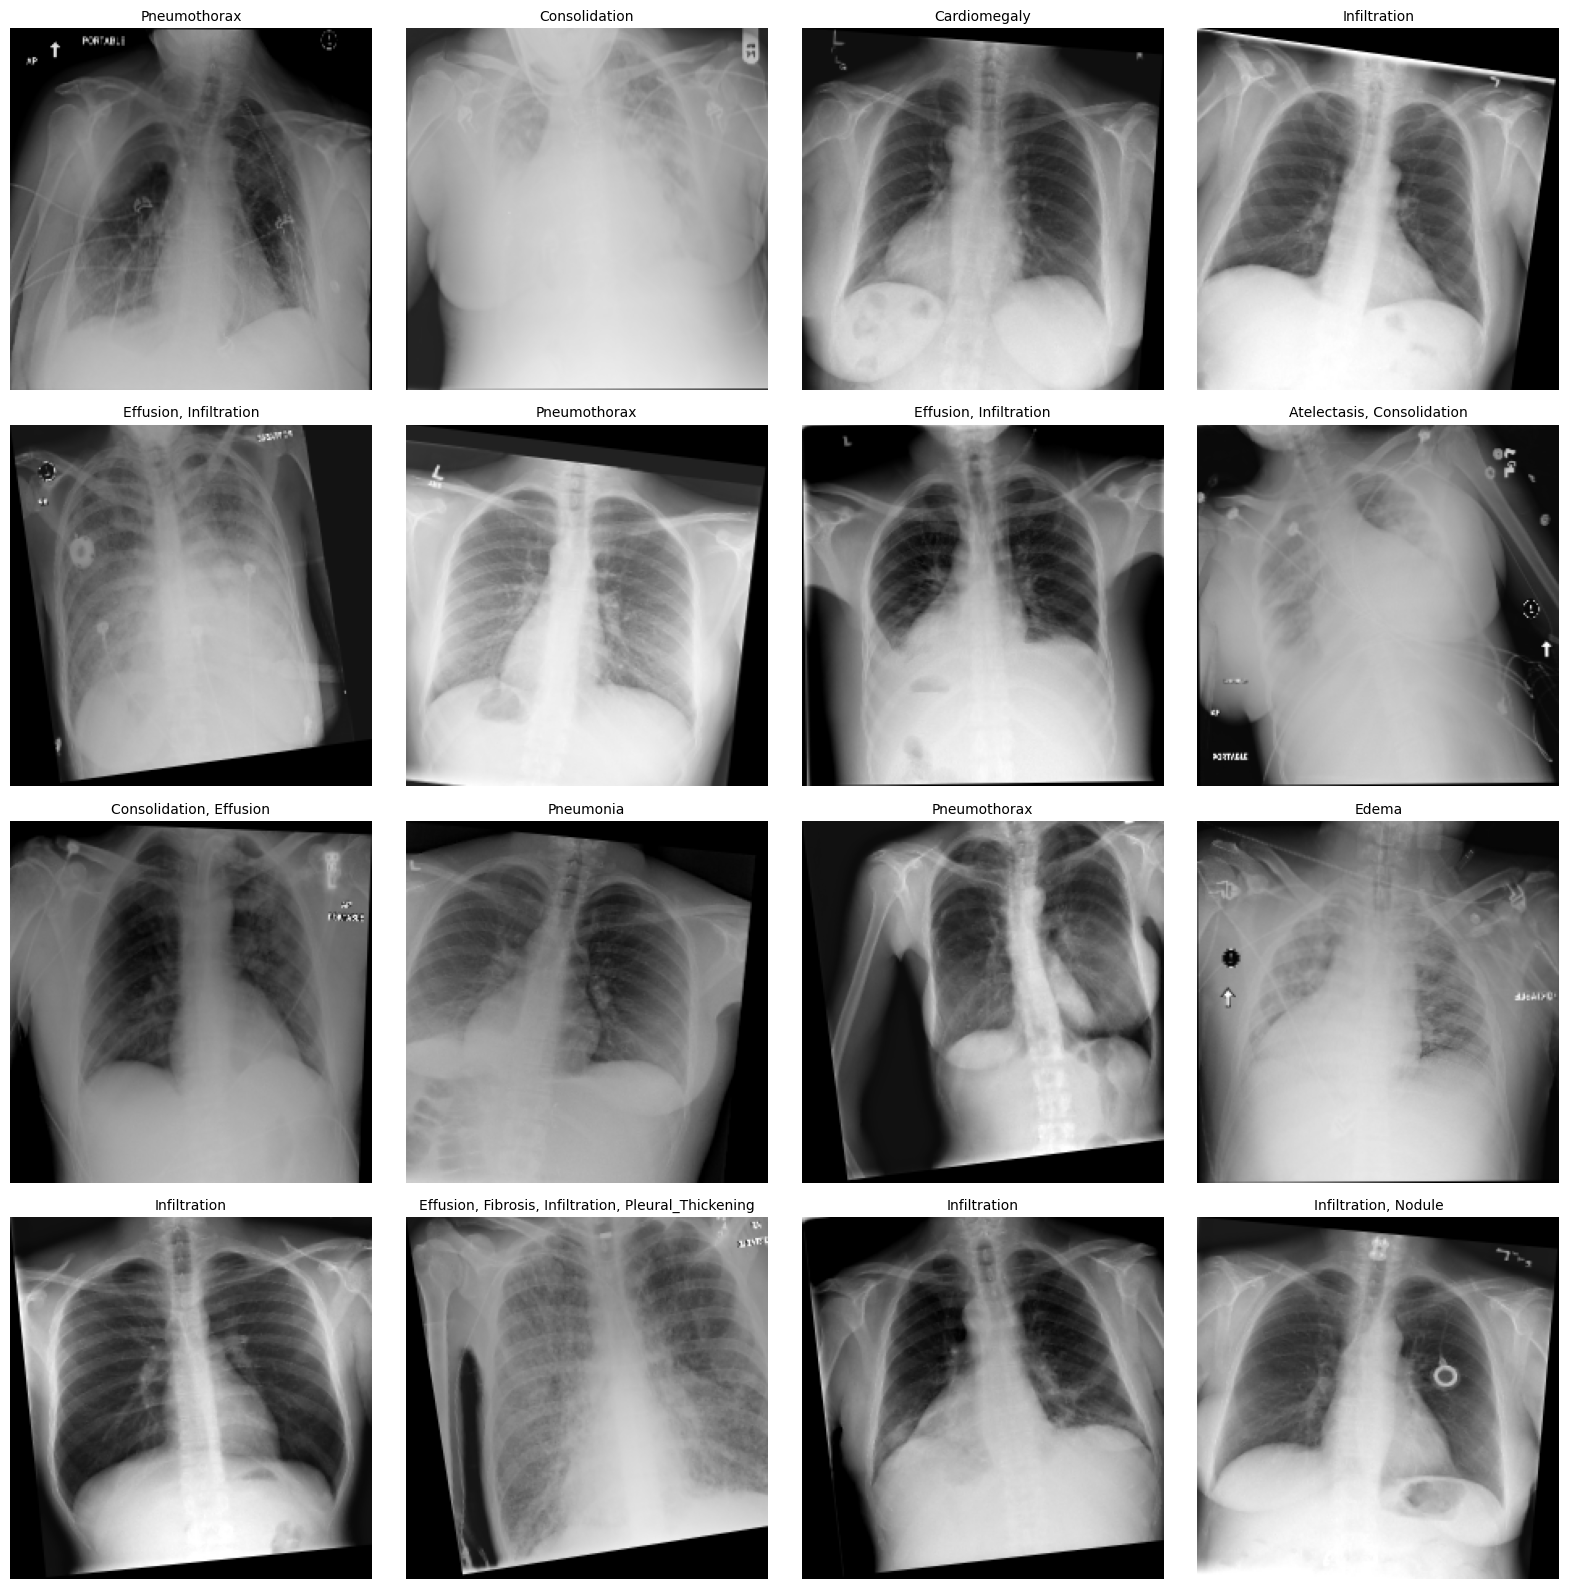

In [4]:
print("Fetching one batch for visualization...")
sample_imgs, sample_labels = next(iter(train_ds))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for img, lbl, ax in zip(sample_imgs[:16], sample_labels[:16], axes.flatten()):
    ax.imshow(img.numpy())
    names = [all_labels[i] for i, v in enumerate(lbl.numpy()) if v > 0.5]
    ax.set_title(', '.join(names) if names else 'No Finding', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
def weighted_binary_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    pos = tf.reduce_sum(y_true, axis=0)
    neg = tf.reduce_sum(1.0 - y_true, axis=0)
    total = pos + neg

    w_pos = tf.math.divide_no_nan(neg, total)
    w_neg = tf.math.divide_no_nan(pos, total)

    loss = -(
        w_pos * y_true * tf.math.log(y_pred) +
        w_neg * (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    )
    # Cast to float32 for numerical stability with mixed precision
    return tf.reduce_mean(tf.cast(loss, tf.float32))

In [6]:
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

with strategy.scope():
    img_in = Input(shape=(224, 224, 3))

    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_tensor=img_in,
        input_shape=(224, 224, 3),
        pooling='avg'
    )

    x = base_model.output

    predictions = Dense(
        len(all_labels), activation="sigmoid",
        name="predictions", dtype='float32'
    )(x)

    model = Model(inputs=img_in, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=weighted_binary_crossentropy,
        metrics=['binary_accuracy']
    )

print("Model compiled with mixed precision")
print(f"Training on {NUM_GPUS} GPU(s)")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model compiled with mixed precision
Training on 2 GPU(s)


In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

lr_decay = ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=1, verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[lr_decay, checkpoint]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

Running predictions on test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 488ms/step

Prediction Frequencies vs Actual Frequencies:
  Atelectasis: actual 22.95%, predicted 42.50%
  Cardiomegaly: actual 5.45%, predicted 27.80%
  Consolidation: actual 9.53%, predicted 44.25%
  Edema: actual 4.78%, predicted 29.61%
  Effusion: actual 26.91%, predicted 37.30%
  Emphysema: actual 4.92%, predicted 29.16%
  Fibrosis: actual 3.06%, predicted 37.82%
  Infiltration: actual 38.50%, predicted 52.43%
  Mass: actual 12.20%, predicted 35.49%
  Nodule: actual 12.35%, predicted 35.20%
  Pleural_Thickening: actual 6.86%, predicted 39.53%
  Pneumonia: actual 2.91%, predicted 43.57%
  Pneumothorax: actual 10.52%, predicted 33.50%


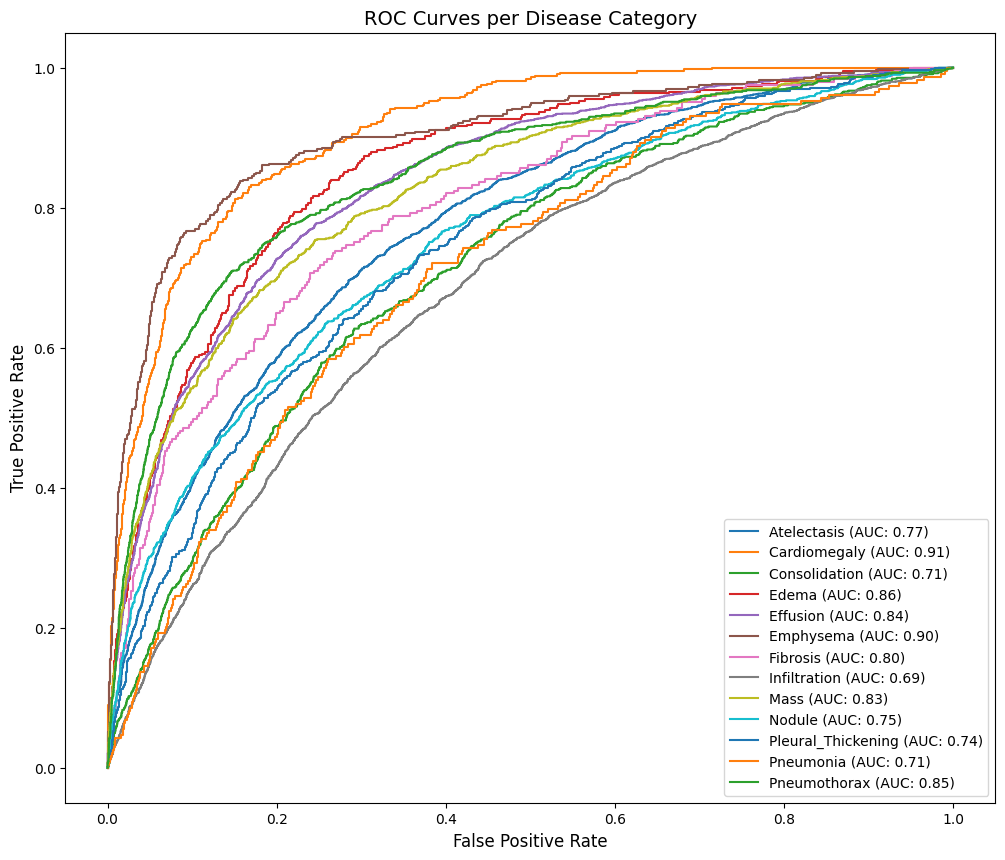


Overall ROC AUC Score: 0.7971


In [18]:
# --- Load best weights ---
model.load_weights('best_model.weights.h5')

# --- Predict on entire test set ---
print("Running predictions on test set...")
test_X_list, test_Y_list = [], []
for imgs, labels in test_ds:
    test_X_list.append(imgs.numpy())
    test_Y_list.append(labels.numpy())

test_X = np.concatenate(test_X_list)
test_Y = np.concatenate(test_Y_list)
y_pred = model.predict(test_X, batch_size=GLOBAL_BATCH_SIZE * 2)

# --- Frequency comparison ---
print("\nPrediction Frequencies vs Actual Frequencies:")
for label, p_pct, t_pct in zip(
    all_labels,
    100 * np.mean(y_pred, axis=0),
    100 * np.mean(test_Y, axis=0)
):
    print(f"  {label}: actual {t_pct:.2f}%, predicted {p_pct:.2f}%")

# --- ROC curves ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for idx, label in enumerate(all_labels):
    fpr, tpr, _ = roc_curve(test_Y[:, idx].astype(int), y_pred[:, idx])
    ax.plot(fpr, tpr, label=f'{label} (AUC: {auc(fpr, tpr):.2f})')

ax.legend(loc='lower right', fontsize=10)
ax.set_title('ROC Curves per Disease Category', fontsize=14)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
fig.savefig('trained_net.png')
plt.show()

overall_auc = roc_auc_score(test_Y.astype(int), y_pred)
print(f'\nOverall ROC AUC Score: {overall_auc:.4f}')

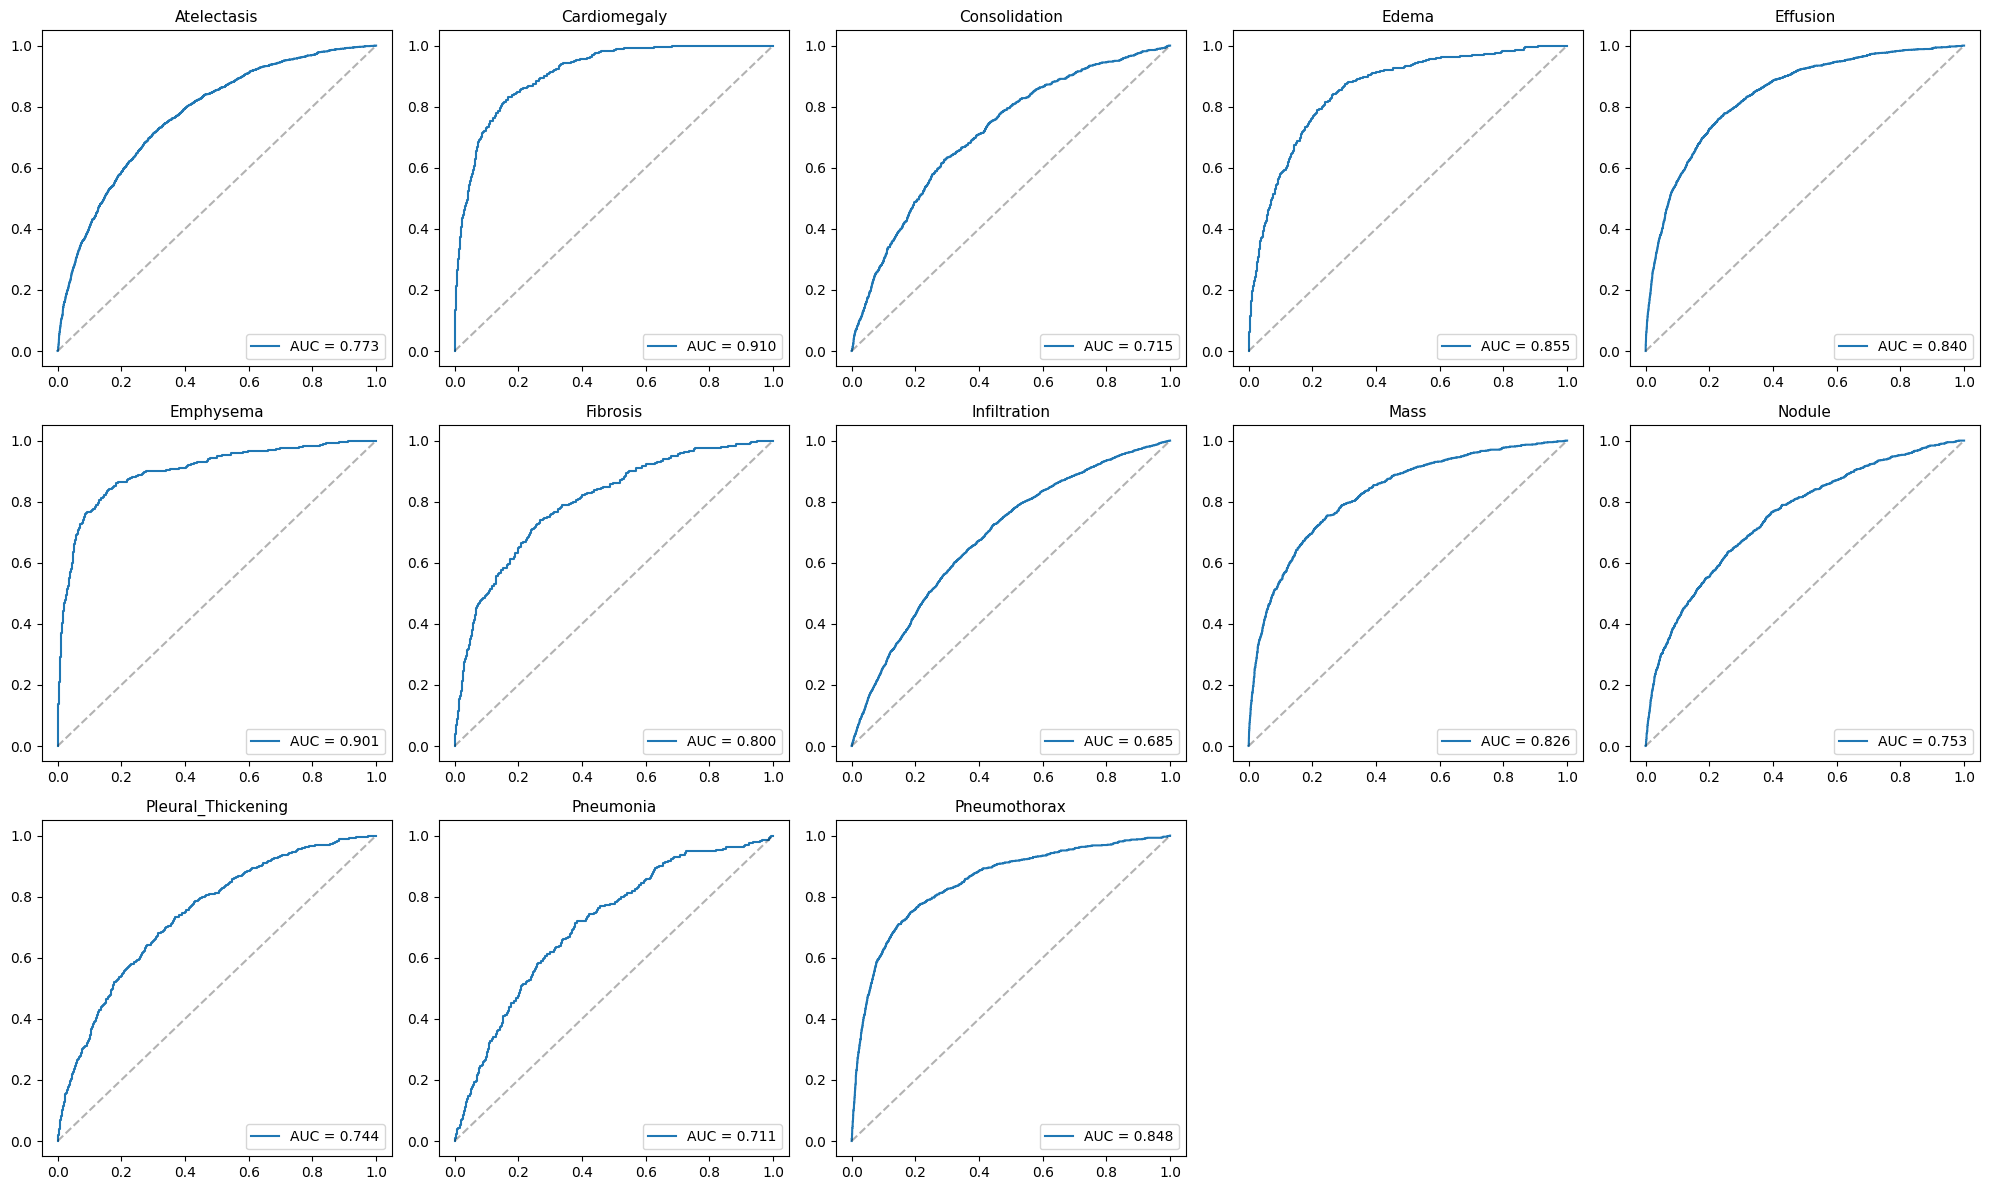


Mean AUC (macro): 0.7971


In [19]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# test_X, test_Y, y_pred are already computed in Cell 7

# --- Per-class AUC ---
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for i, (label, ax) in enumerate(zip(all_labels, axes.flatten())):
    fpr, tpr, _ = roc_curve(test_Y[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(label, fontsize=11)
    ax.legend(loc='lower right')

# hide any extra subplots
for j in range(len(all_labels), len(axes.flatten())):
    axes.flatten()[j].axis('off')

plt.tight_layout()
plt.show()

# --- Overall mean AUC ---
mean_auc = roc_auc_score(test_Y, y_pred, average='macro')
print(f"\nMean AUC (macro): {mean_auc:.4f}")

In [20]:
from sklearn.metrics import classification_report

y_binary = (y_pred >= 0.5).astype(int)
print(classification_report(test_Y, y_binary, target_names=all_labels, zero_division=0))

                    precision    recall  f1-score   support

       Atelectasis       0.42      0.69      0.52      1836
      Cardiomegaly       0.22      0.82      0.35       436
     Consolidation       0.16      0.70      0.26       762
             Edema       0.15      0.79      0.26       382
          Effusion       0.59      0.69      0.64      2153
         Emphysema       0.20      0.85      0.33       394
          Fibrosis       0.07      0.77      0.13       245
      Infiltration       0.50      0.73      0.59      3080
              Mass       0.35      0.67      0.46       976
            Nodule       0.33      0.47      0.39       988
Pleural_Thickening       0.14      0.66      0.23       549
         Pneumonia       0.06      0.65      0.10       233
      Pneumothorax       0.31      0.75      0.44       842

         micro avg       0.28      0.70      0.40     12876
         macro avg       0.27      0.71      0.36     12876
      weighted avg       0.39      0.7

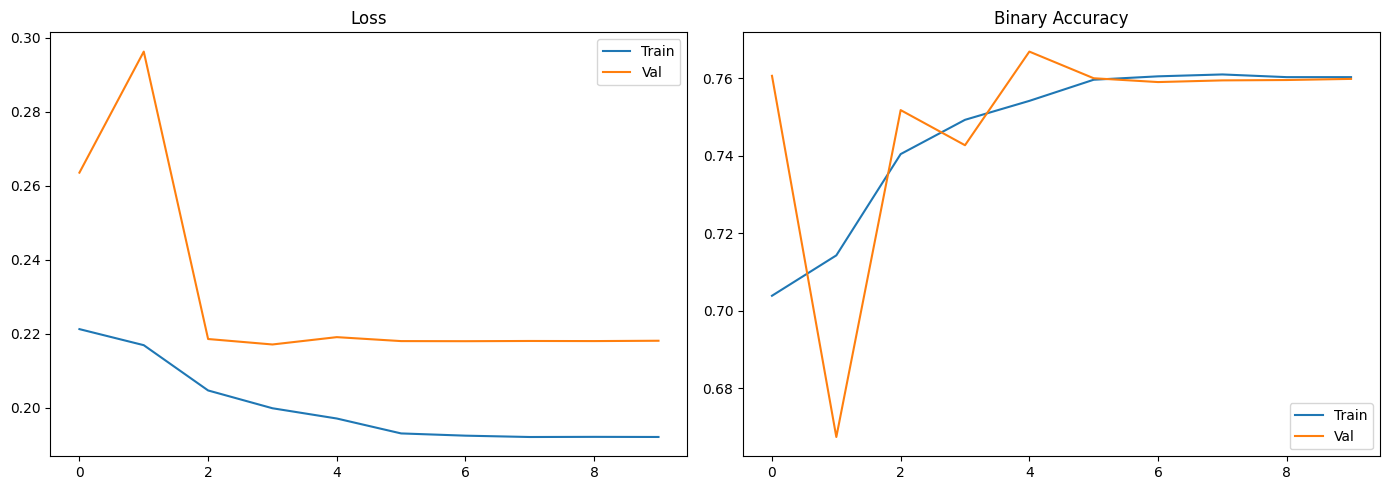

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.legend()

ax2.plot(history.history['binary_accuracy'], label='Train')
ax2.plot(history.history['val_binary_accuracy'], label='Val')
ax2.set_title('Binary Accuracy'); ax2.legend()

plt.tight_layout(); plt.show()

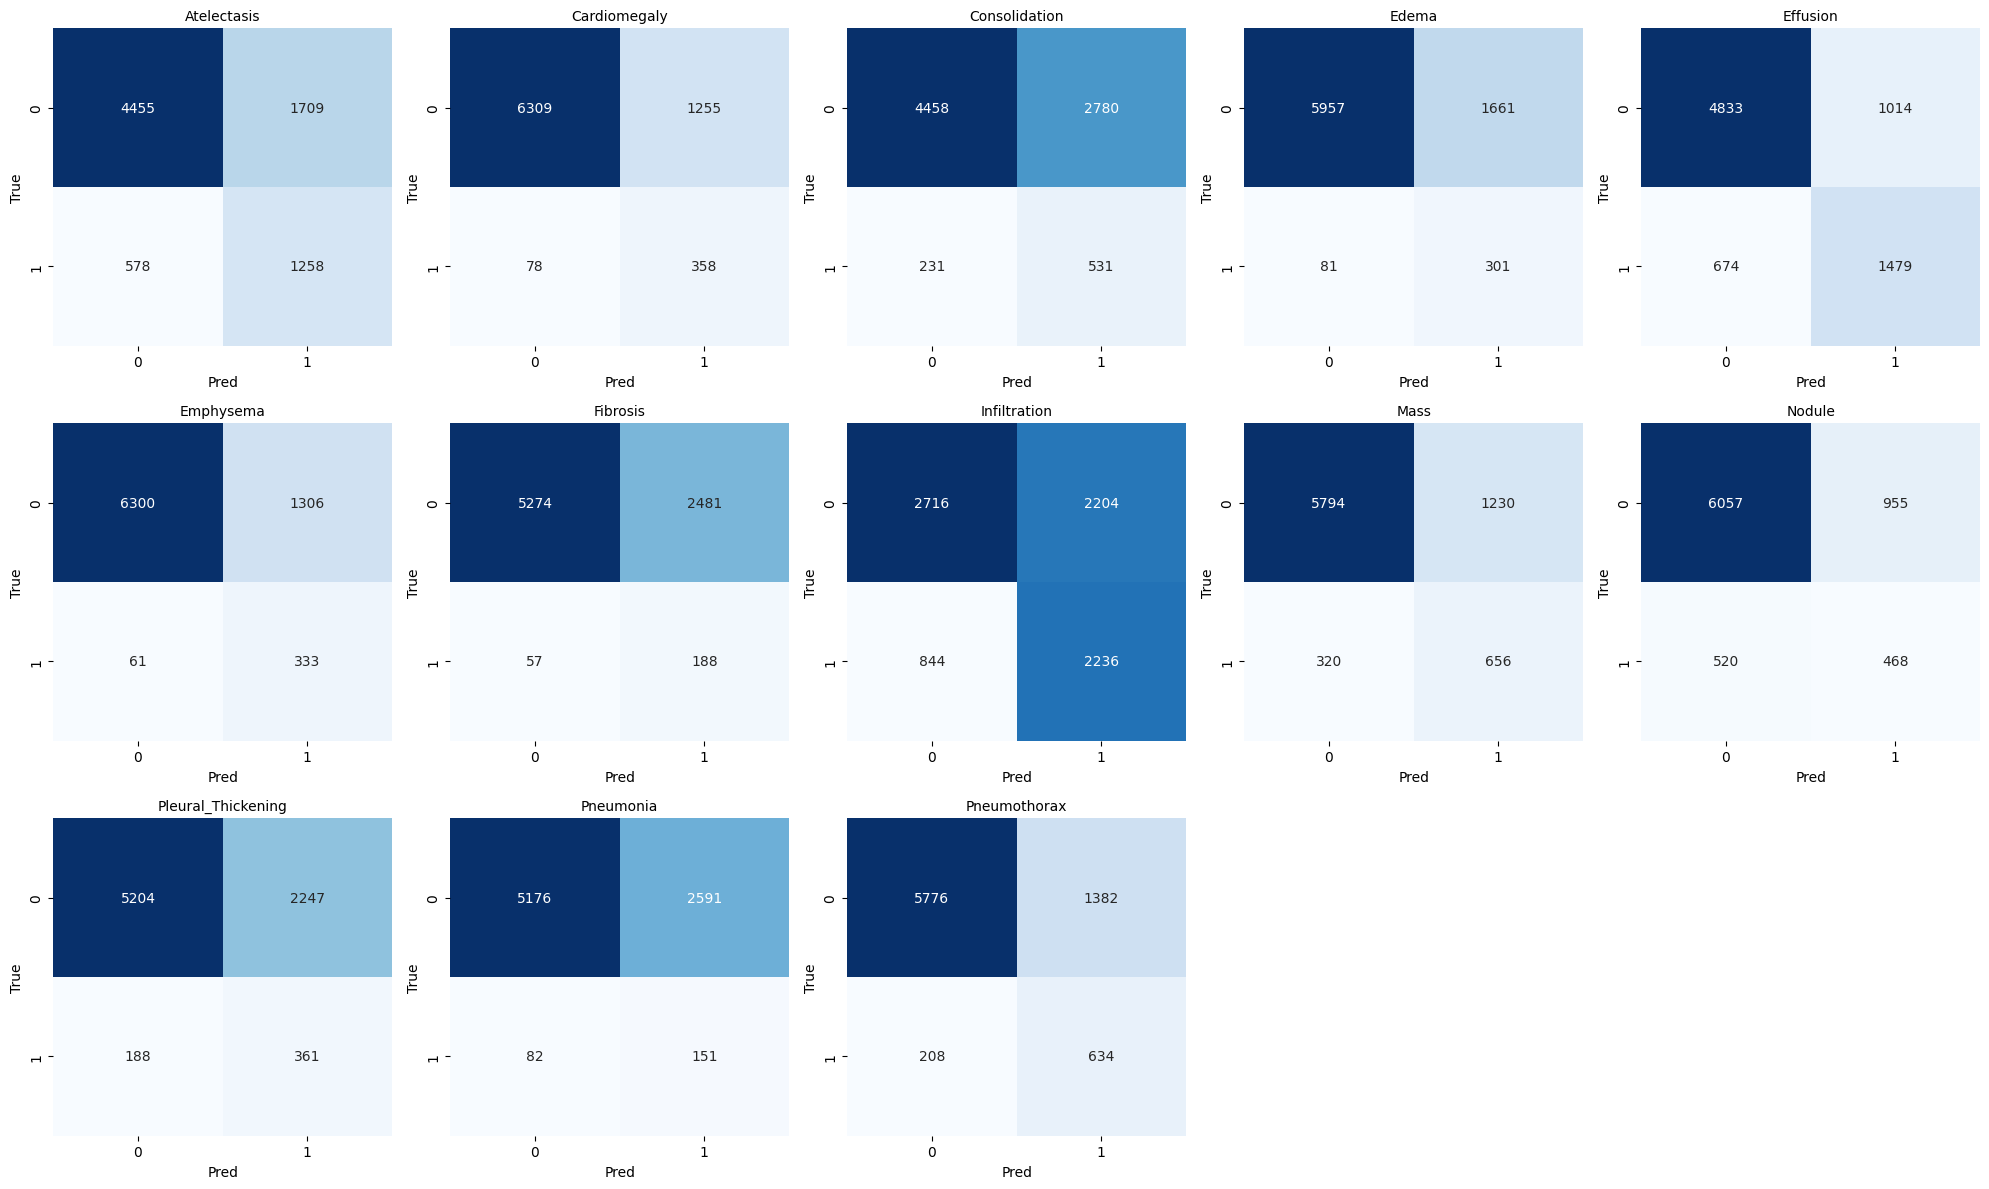

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for i, (label, ax) in enumerate(zip(all_labels, axes.flatten())):
    cm = confusion_matrix(test_Y[:, i], y_binary[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Pred'); ax.set_ylabel('True')

for j in range(len(all_labels), len(axes.flatten())):
    axes.flatten()[j].axis('off')
plt.tight_layout(); plt.show()

Using layer: conv5_block16_concat


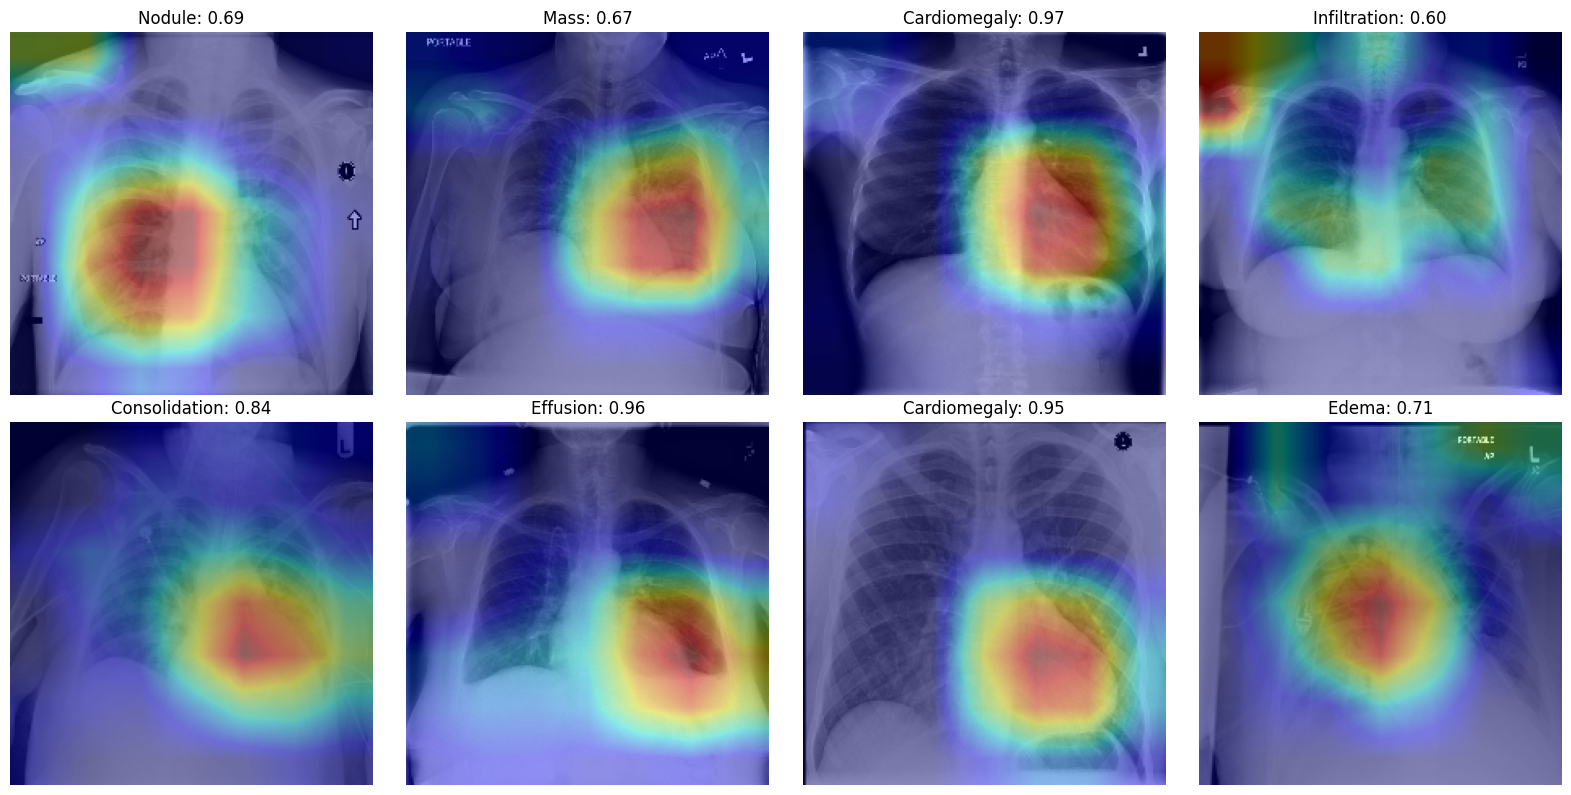

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

last_conv_layer = [l.name for l in model.layers if 'conv' in l.name][-1]
print(f"Using layer: {last_conv_layer}")

grad_model = tf.keras.Model(
    inputs=model.input,
    outputs=[model.get_layer(last_conv_layer).output, model.output]
)

def get_gradcam(img_tensor, class_idx):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor[tf.newaxis, ...])
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(conv_out * weights[..., tf.newaxis, tf.newaxis, :], axis=-1)
    cam = tf.nn.relu(cam)[0]
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, ax in enumerate(axes.flatten()):
    img = test_X[idx]
    top_class = np.argmax(y_pred[idx])
    cam = get_gradcam(tf.constant(img), top_class)
    cam_resized = tf.image.resize(cam[..., tf.newaxis], (224, 224)).numpy().squeeze()
    ax.imshow(img)
    ax.imshow(cam_resized, alpha=0.4, cmap='jet')
    ax.set_title(f"{all_labels[top_class]}: {y_pred[idx][top_class]:.2f}")
    ax.axis('off')
plt.tight_layout()
plt.show()